In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.patches as mpatches


In [2]:
with open('/n/tambe_lab/Everyone/tree_mapping/results.json') as f:
    results = json.load(f)

In [3]:
def get_results_by_strata(results, reference_maps, trained_maps, strata_type):
    results_by_stratum_df = pd.DataFrame()

    strata = list(results[reference_maps[0]][strata_type].keys())
    for ref_map in reference_maps:
        for stratum in strata:
            row_dict = results[ref_map][strata_type][f'{stratum}']
            row_dict.update({'map_type': ref_map, strata_type: stratum})
            row = pd.DataFrame([row_dict])
            results_by_stratum_df = pd.concat((results_by_stratum_df,row))


    for trained_map in trained_maps:
        for trial_seed in range(10):
            for stratum in strata:
                row_dict = results[trained_map]['12 train sites'][f'seed {trial_seed}'][strata_type][f'{stratum}']
                row_dict.update({'trial_seed': trial_seed, 'map_type': trained_map, strata_type: stratum})
                row = pd.DataFrame([row_dict])
                results_by_stratum_df = pd.concat((results_by_stratum_df,row))
    return results_by_stratum_df

In [4]:
reference_maps = ['ETH', 'GLAD', 'META', 'PAULS']
trained_maps = [f'local_only_models/128_filters/{x}' for x in ['12_channels']]

In [5]:
results_by_split_df = get_results_by_strata(results,reference_maps, trained_maps, strata_type='split')

# a. compare aggregate quantitative performance

/tmp/ipykernel_624276/2979655232.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([label_names_dict[x.get_text()] for x in ax[0].get_xticklabels()],


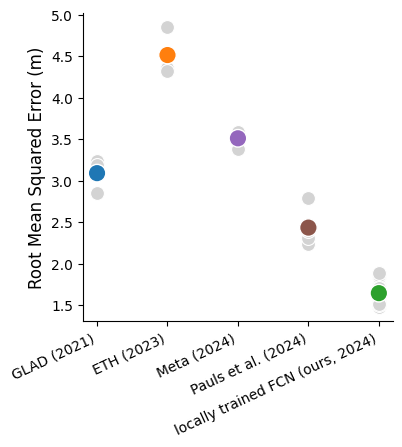

In [6]:
# sort by date
methods_compare = ['GLAD', 'ETH',  'META',  'PAULS',
                   f'local_only_models/128_filters/12_channels'
                  ]
colors_dict = {'ETH':sns.color_palette()[0],
                    'GLAD':sns.color_palette()[1],
                    'META':sns.color_palette()[4],
                    'PAULS':sns.color_palette()[5],
                   'local_only_models/128_filters/12_channels': sns.color_palette()[2]
              }
colors = [colors_dict[x] for x in methods_compare]
results_by_split_df_condensed = pd.DataFrame()
for method_name in methods_compare:
    results_by_split_df_condensed = pd.concat((results_by_split_df_condensed,
                                              results_by_split_df[results_by_split_df['map_type'].apply(lambda x: x == method_name)]))

y_key = 'rmse'
metric_labels = {'mae': "Mean Absolute Error (m)", 'rmse': "Root Mean Squared Error (m)"}

label_names_dict = {'ETH':'ETH (2023)', 
                    'GLAD':'GLAD (2021)', 
                    'META':'Meta (2024)', 
                    'PAULS':'Pauls et al. (2024)', 
                    'local_only_models/128_filters/3_channels': 'FCN 3 channels (ours)',
                   'local_only_models/128_filters/4_channels': 'FCN 4 channels (ours)',
                   'local_only_models/128_filters/12_channels': 'locally trained FCN (ours, 2024)',
                   'local_only_models/128_filters/15_channels': 'FCN 15 channels (ours)'}



fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)
ax = [ax]

sns.scatterplot(data=results_by_split_df_condensed, x='map_type',y=y_key, 
                s=100,
                color='lightgrey', #label='each of 4 test splits',
               ax=ax[0])
sns.scatterplot(data=results_by_split_df_condensed.groupby('map_type')[[y_key]].mean(), x='map_type', y=y_key, 
                s=160,
                c=colors, 
  #              c = [sns.color_palette("tab10")[x] for x in [4,0,1,5,2]],
              #  label='average across test splits',
               ax=ax[0])

ax[0].set_ylabel(metric_labels[y_key], fontsize='large')
for i in range(len(ax)):
    ax[i].set_xlabel(None)
    
ax[0].set_xticklabels([label_names_dict[x.get_text()] for x in ax[0].get_xticklabels()], 
                      rotation=25, horizontalalignment='right')
sns.despine()

#ax[0].set_title('(a) Aggregate Performance')
plt.savefig('../figures/quantitative_performance.png', bbox_inches='tight', dpi=300)

In [7]:
def plot_signed_errors_by_strata(results_stratified, strata_key, methods_compare, ax=None, legend=True):
    if ax is None: 
        fig, ax = plt.subplots()
        
    bins = results_stratified[strata_key].unique()
    num_bins = len(bins)

    print(methods_compare)
    for m, model_name in enumerate(methods_compare):
        offset = m * (0.8 / len(methods_compare))
        intervals = []

        results_this_model = results_stratified[results_stratified['map_type'] == model_name].copy()
        if model_name in trained_maps:
            results_this_model = results_this_model[results_this_model['trial_seed'] == 0]
        for i, this_bin in enumerate(bins):
            #interval = f'{height_interval_bounds[i]}-{height_interval_bounds[i+1]}'
            if i == 0: label=label_names_dict[model_name]
            else: label=None

            results_this_bin = results_this_model[results_this_model[strata_key] == this_bin]
            med = results_this_bin['median']
            q10 = results_this_bin['perc_10']
            q90 = results_this_bin['perc_90']
            ax.scatter([i+offset], [med], color=colors_dict[model_name], marker='s',
                       label=label, s=48)
            ax.errorbar([i+offset], 
                        y= [med],
                        yerr=(med-q10, q90-med), 
                        color=colors_dict[model_name])
    
    ax.axhline(0, color='black', zorder=-1)
    
    if strata_key in ['height', 'river']: names = [f'{bin_this}m' for bin_this in bins]
    else: names = [f'{bin_this}' for bin_this in bins]
    ax.set_xticks(np.arange(len(bins))+0.4, names, rotation=20,horizontalalignment='right')
    sns.despine()
    if legend: plt.legend(loc='lower left')
    
    ax.set_ylabel('signed error (m)', fontsize=12)
    
    return ax

['GLAD', 'ETH', 'META', 'PAULS', 'local_only_models/128_filters/12_channels']
['GLAD', 'ETH', 'META', 'PAULS', 'local_only_models/128_filters/12_channels']


/n/home10/erolf/.conda/envs/tree_mapping/lib/python3.10/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/n/home10/erolf/.conda/envs/tree_mapping/lib/python3.10/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/n/home10/erolf/.conda/envs/tree_mapping/lib/python3.10/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


['GLAD', 'ETH', 'META', 'PAULS', 'local_only_models/128_filters/12_channels']


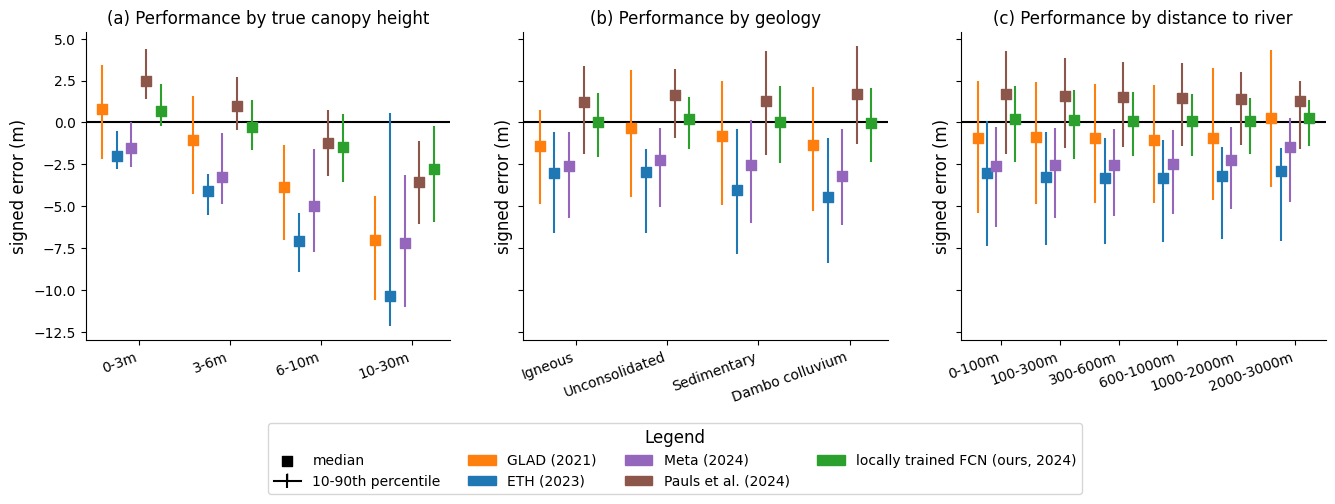

In [8]:
strata_keys = ['height', 'geology', 'river']
titles = ['(a) Performance by true canopy height',
          '(b) Performance by geology',
          '(c) Performance by distance to river'
         ]
#fig, ax = plt.subplots(1,len(strata_keys), figsize=(len(strata_keys)*5,5), sharey=True)
fig, ax = plt.subplots(1,3, figsize=(16,4), sharey=True)

tiles = {0: 0, 1: 1, 2: 2}
for s,strata_key in enumerate(strata_keys):
    results_by_strata_df = get_results_by_strata(results,reference_maps, trained_maps, strata_type=strata_key)

    plot_signed_errors_by_strata(results_by_strata_df, strata_key, methods_compare, ax=ax[tiles[s]], legend=False);
    ax[tiles[s]].set_title(titles[s])

# ax[3].clear()
# ax[3].set_axis_off()


median = ax[2].scatter([], [], color='black', marker='s',
                       label='median', s=48)
bar = ax[2].errorbar([], 
                        y= [],
                        yerr=[], 
                        color='black',
                 marker=s,
                label='10-90th percentile')

patches = [median, bar]
for name in methods_compare:
    patches.append(mpatches.Patch(color=colors_dict[name], label=label_names_dict[name]))

legend = ax[2].legend(handles=patches,
               loc=(-1.9,-.5), title='Legend', ncols=4)#, fontsize='medium')
plt.setp(legend.get_title(),fontsize='large')

plt.savefig('../figures/quantitative_performance_stratified.png', bbox_inches='tight', dpi=300)